# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom, poisson

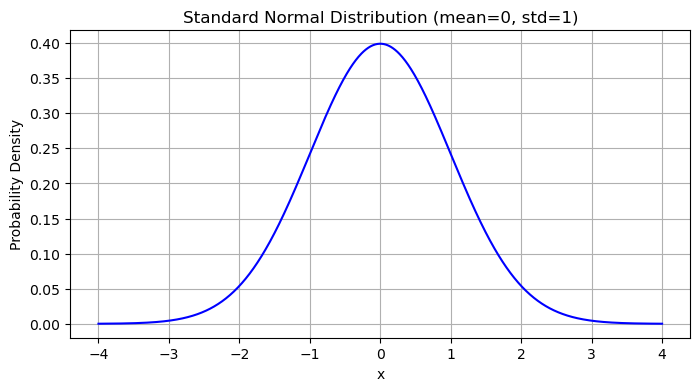

Percentage of students scoring above 85: 7.10%


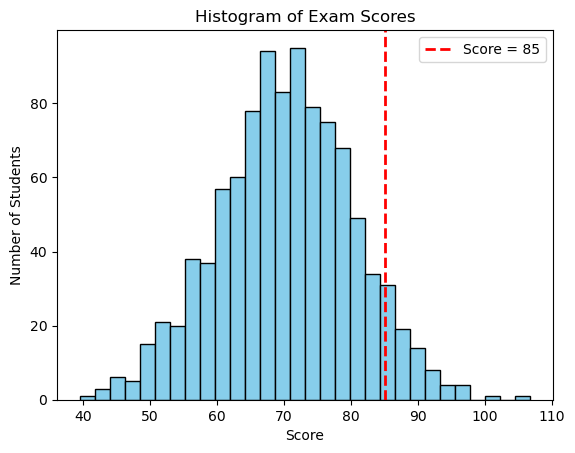

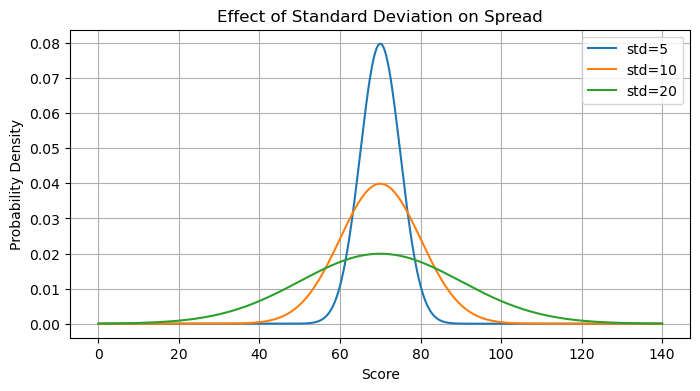

In [2]:
# Your code here

# Q1: Generate standard normal distribution

mean = 0
std = 1
x = np.linspace(-4, 4, 1000)  # range for plotting
y = norm.pdf(x, mean, std)

plt.figure(figsize=(8,4))
plt.plot(x, y, color='blue')
plt.title("Standard Normal Distribution (mean=0, std=1)")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.grid(True)
plt.show()

# Q2: Simulate exam scores for 1000 students

exam_mean = 70
exam_std = 10
scores = np.random.normal(exam_mean, exam_std, 1000)

# % of students scoring above 85

above_85 = np.sum(scores > 85)
percent_above_85 = (above_85 / len(scores)) * 100
print(f"Percentage of students scoring above 85: {percent_above_85:.2f}%")

# Histogram

plt.hist(scores, bins=30, color='skyblue', edgecolor='black')
plt.axvline(85, color='red', linestyle='dashed', linewidth=2, label='Score = 85')
plt.title("Histogram of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

# Q3: Effect of changing standard deviation

std_values = [5, 10, 20]
x = np.linspace(0, 140, 1000)
plt.figure(figsize=(8,4))
for s in std_values:
    plt.plot(x, norm.pdf(x, exam_mean, s), label=f'std={s}')
plt.title("Effect of Standard Deviation on Spread")
plt.xlabel("Score")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

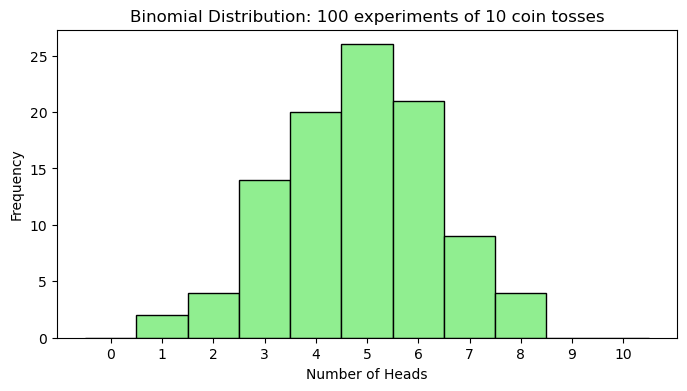

Probability of exactly 6 correct out of 10: 0.0162


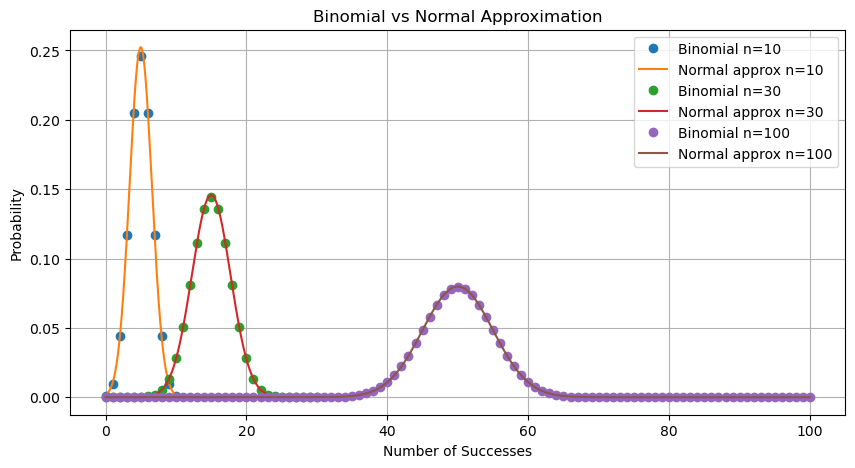

In [3]:
# Your code here

# Q4: Simulate 100 coin toss experiments

n_tosses = 10
p_coin = 0.5
experiments = 100

# Simulate

results = np.random.binomial(n_tosses, p_coin, experiments)

# Plot

plt.figure(figsize=(8,4))
plt.hist(results, bins=np.arange(-0.5, n_tosses+1, 1), edgecolor='black', color='lightgreen')
plt.title(f"Binomial Distribution: {experiments} experiments of {n_tosses} coin tosses")
plt.xlabel("Number of Heads")
plt.ylabel("Frequency")
plt.xticks(range(n_tosses+1))
plt.show()

# Q5: Probability of getting exactly 6 correct in 10 MCQs

n_mcq = 10
p_guess = 0.25
k = 6

prob_6_correct = binom.pmf(k, n_mcq, p_guess)
print(f"Probability of exactly 6 correct out of 10: {prob_6_correct:.4f}")

# Q6: When does binomial resemble normal?
# Idea: Large n and p not too close to 0 or 1

n_values = [10, 30, 100]
p_binom = 0.5
x = np.arange(0, 101)

plt.figure(figsize=(10,5))
for n in n_values:
    binom_probs = binom.pmf(np.arange(0, n+1), n, p_binom)
    
    mean = n * p_binom
    std = np.sqrt(n * p_binom * (1-p_binom))
    x_norm = np.linspace(0, n, 1000)
    norm_curve = norm.pdf(x_norm, mean, std)
    
    plt.plot(np.arange(0, n+1), binom_probs, 'o', label=f'Binomial n={n}')
    plt.plot(x_norm, norm_curve, '-', label=f'Normal approx n={n}')
    
plt.title("Binomial vs Normal Approximation")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

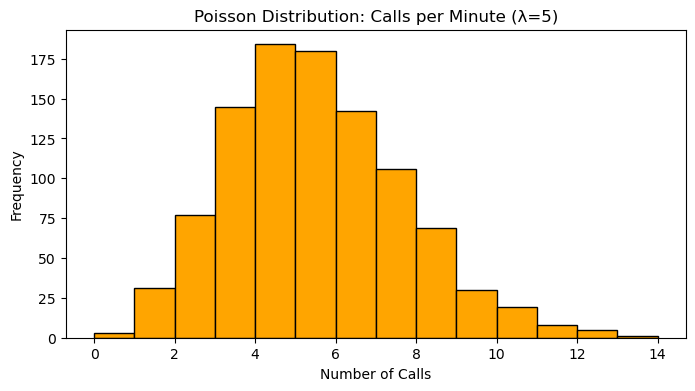

Probability of exactly 3 calls in a minute: 0.1404


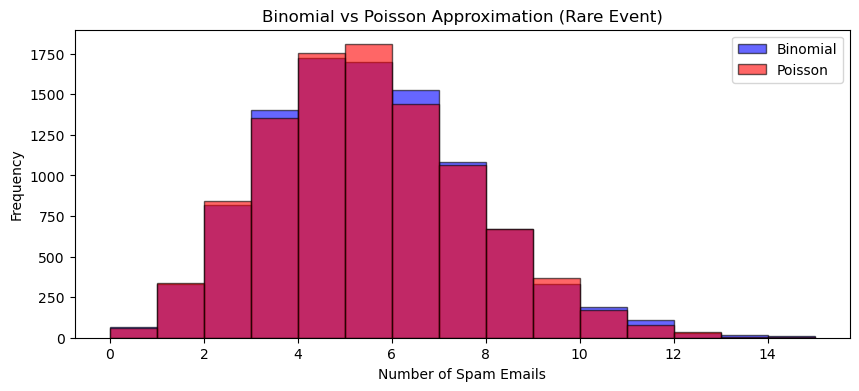

In [4]:
# Your code here

# Q7: Simulate number of calls per minute

lambda_calls = 5
minutes = 1000  # simulate 1000 minutes
calls_per_minute = np.random.poisson(lambda_calls, minutes)

# Plot histogram

plt.figure(figsize=(8,4))
plt.hist(calls_per_minute, bins=range(0, max(calls_per_minute)+2), edgecolor='black', color='orange')
plt.title(f"Poisson Distribution: Calls per Minute (λ={lambda_calls})")
plt.xlabel("Number of Calls")
plt.ylabel("Frequency")
plt.show()

# Q8: Probability of exactly 3 calls

prob_3_calls = poisson.pmf(3, lambda_calls)
print(f"Probability of exactly 3 calls in a minute: {prob_3_calls:.4f}")

# Q9: When to use Poisson vs Binomial

# Poisson is used for rare events in large n, small p scenario (events per time/space)

# Example: Suppose 1 in 1000 emails is spam (p=0.001), and 5000 emails received

n_emails = 5000
p_spam = 0.001

spam_binom = np.random.binomial(n_emails, p_spam, 10000)

lambda_poisson = n_emails * p_spam
spam_poisson = np.random.poisson(lambda_poisson, 10000)

plt.figure(figsize=(10,4))
plt.hist(spam_binom, bins=range(min(spam_binom), max(spam_binom)+1), alpha=0.6, label='Binomial', color='blue', edgecolor='black')
plt.hist(spam_poisson, bins=range(min(spam_poisson), max(spam_poisson)+1), alpha=0.6, label='Poisson', color='red', edgecolor='black')
plt.title("Binomial vs Poisson Approximation (Rare Event)")
plt.xlabel("Number of Spam Emails")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

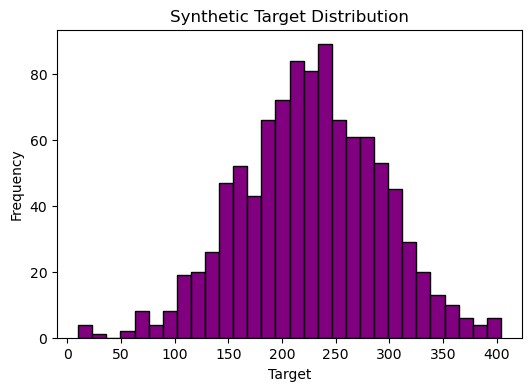

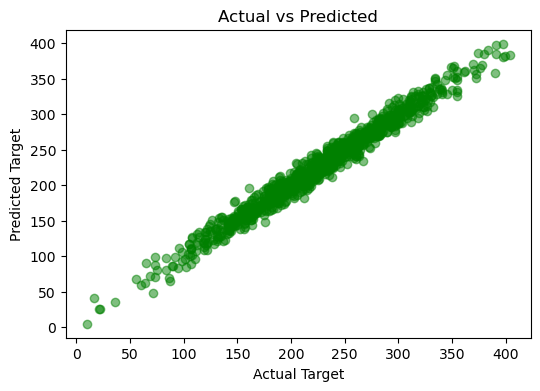

KS Test for Normal Fit: statistic=0.0191, p-value=0.8502
Fail to reject H0 → Normal distribution is a reasonable fit.


In [5]:
# Your code here

# Extra imports for pipeline and modeling

from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm, binom, poisson

# Q10: Create synthetic dataset where target follows normal distribution

X, y = make_regression(n_samples=1000, n_features=5, noise=10, random_state=42)
y = y - y.min() + 10

plt.figure(figsize=(6,4))
plt.hist(y, bins=30, color='purple', edgecolor='black')
plt.title("Synthetic Target Distribution")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()

# Q11: Build sklearn pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),      
    ('regressor', LinearRegression()) 
])

# Fit pipeline

pipeline.fit(X, y)
y_pred = pipeline.predict(X)

# Check predictions

plt.figure(figsize=(6,4))
plt.scatter(y, y_pred, alpha=0.5, color='green')
plt.title("Actual vs Predicted")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.show()

# Q12: Identify best-fitting distribution

mu, std = norm.fit(y)
ks_stat, p_value = kstest(y, 'norm', args=(mu, std))
print(f"KS Test for Normal Fit: statistic={ks_stat:.4f}, p-value={p_value:.4f}")

if p_value > 0.05:
    print("Fail to reject H0 → Normal distribution is a reasonable fit.")
else:
    print("Reject H0 → Normal distribution may not be a good fit.")

## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


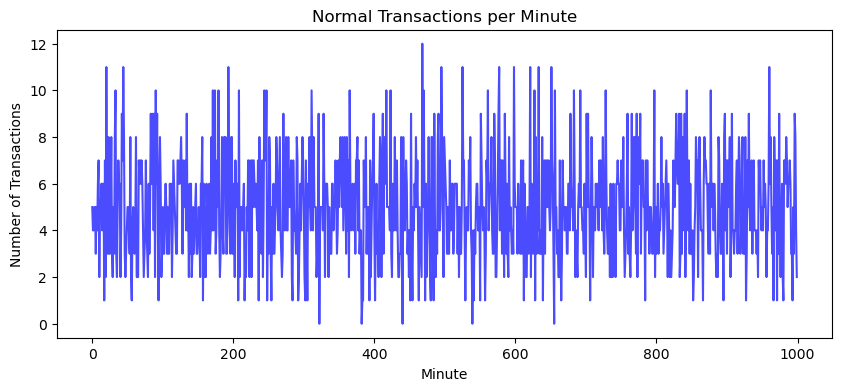

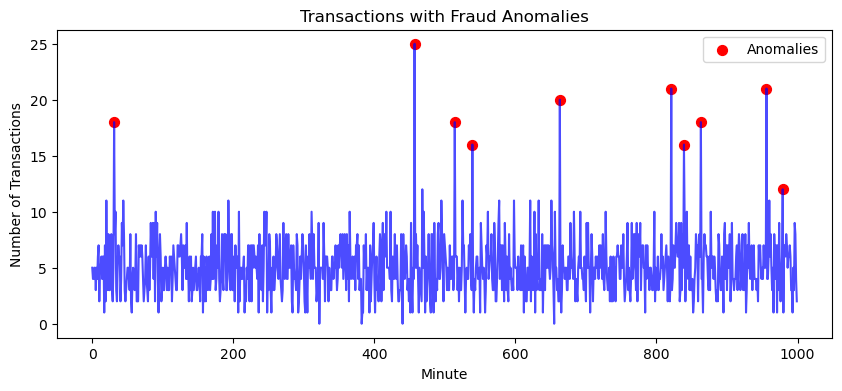

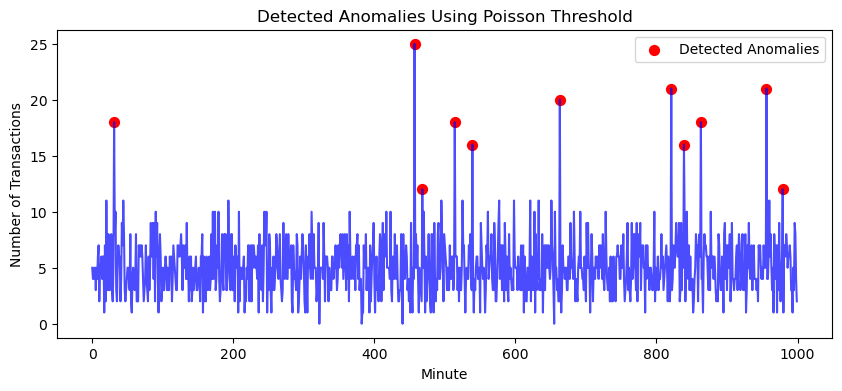

Detected anomaly indices: [31, 457, 468, 514, 539, 663, 821, 839, 863, 956, 979]

Ideas to reduce false positives:
1. Adjust λ dynamically using rolling mean of recent data.
2. Use higher threshold (e.g., 0.001) for rare events.
3. Combine Poisson check with other features: transaction amount, user history.
4. Smooth data or use moving average to avoid spikes triggering alerts.
5. Consider clustering multiple high transactions before flagging as anomaly.



In [6]:
# Your code here

# Q13: Simulate normal transaction behavior

np.random.seed(42)
lambda_normal = 5
minutes = 1000
transactions = np.random.poisson(lambda_normal, minutes)

plt.figure(figsize=(10,4))
plt.plot(transactions, color='blue', alpha=0.7)
plt.title("Normal Transactions per Minute")
plt.xlabel("Minute")
plt.ylabel("Number of Transactions")
plt.show()

# Q14: Inject anomalies (fraud spikes)

anomalies_idx = np.random.choice(np.arange(minutes), size=10, replace=False)
transactions[anomalies_idx] += np.random.randint(10, 20, size=10)  # spike transactions

plt.figure(figsize=(10,4))
plt.plot(transactions, color='blue', alpha=0.7)
plt.scatter(anomalies_idx, transactions[anomalies_idx], color='red', label='Anomalies', s=50)
plt.title("Transactions with Fraud Anomalies")
plt.xlabel("Minute")
plt.ylabel("Number of Transactions")
plt.legend()
plt.show()

# Q15: Detect anomalies using Poisson probability threshold

threshold = 0.01
detected_anomalies = [i for i, t in enumerate(transactions) if poisson.sf(t-1, lambda_normal) < threshold]

plt.figure(figsize=(10,4))
plt.plot(transactions, color='blue', alpha=0.7)
plt.scatter(detected_anomalies, transactions[detected_anomalies], color='red', label='Detected Anomalies', s=50)
plt.title("Detected Anomalies Using Poisson Threshold")
plt.xlabel("Minute")
plt.ylabel("Number of Transactions")
plt.legend()
plt.show()

print(f"Detected anomaly indices: {detected_anomalies}")

# Q16 (Thinking): Reducing false positives

print("""
Ideas to reduce false positives:
1. Adjust λ dynamically using rolling mean of recent data.
2. Use higher threshold (e.g., 0.001) for rare events.
3. Combine Poisson check with other features: transaction amount, user history.
4. Smooth data or use moving average to avoid spikes triggering alerts.
5. Consider clustering multiple high transactions before flagging as anomaly.
""")

## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [7]:
# Your code here

# Extra import for widgets

import ipywidgets as widgets
from IPython.display import display

# Function to plot distributions

def plot_distributions(mean=0, std=1, lambda_poisson=5):
    plt.figure(figsize=(12,4))

    # Normal distribution
    
    plt.subplot(1,2,1)
    x = np.linspace(mean - 4*std, mean + 4*std, 1000)
    plt.plot(x, norm.pdf(x, mean, std), color='blue')
    plt.title(f"Normal Distribution (μ={mean}, σ={std})")
    plt.xlabel("x")
    plt.ylabel("Probability Density")
    
    # Poisson distribution
    
    plt.subplot(1,2,2)
    x_poisson = np.arange(0, lambda_poisson*3)
    plt.bar(x_poisson, poisson.pmf(x_poisson, lambda_poisson), color='orange', edgecolor='black')
    plt.title(f"Poisson Distribution (λ={lambda_poisson})")
    plt.xlabel("k")
    plt.ylabel("Probability")
    
    plt.tight_layout()
    plt.show()

# Create sliders

mean_slider = widgets.FloatSlider(value=0, min=-10, max=10, step=0.5, description='Mean μ:')
std_slider = widgets.FloatSlider(value=1, min=0.1, max=10, step=0.1, description='Std σ:')
lambda_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Lambda λ:')

ui = widgets.HBox([mean_slider, std_slider, lambda_slider])

out = widgets.interactive_output(plot_distributions, {'mean': mean_slider, 'std': std_slider, 'lambda_poisson': lambda_slider})

display(ui, out)

Output()

## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q19:** Use likelihood or visual comparison to decide best fit.


Normal fit: μ=3.93, σ=1.97
Poisson fit: λ=3.93
Binomial fit: n=10, p=0.39


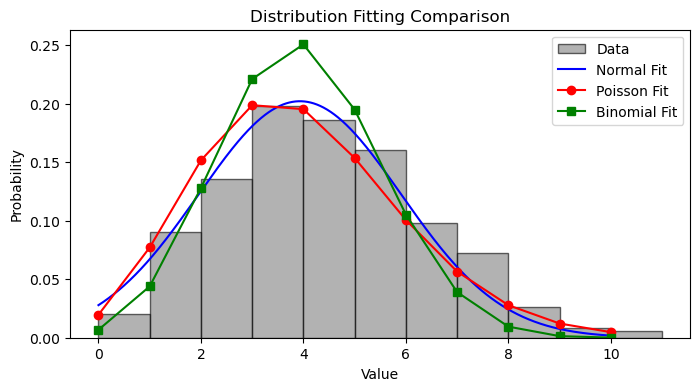

Decision: Based on visual comparison, Poisson distribution best fits this dataset.


In [8]:
# Your code here

# Create example dataset (synthetic)

np.random.seed(42)

# For illustration, dataset is roughly Poisson

data = np.random.poisson(lam=4, size=500)

# Fit Normal distribution

mu_norm, std_norm = norm.fit(data)

# Fit Poisson distribution (lambda = mean of data)

lambda_poisson = data.mean()

# Fit Binomial (approximate n and p)

n_binom = data.max()
p_binom = data.mean() / n_binom

print(f"Normal fit: μ={mu_norm:.2f}, σ={std_norm:.2f}")
print(f"Poisson fit: λ={lambda_poisson:.2f}")
print(f"Binomial fit: n={n_binom}, p={p_binom:.2f}")

# Visual comparison

plt.figure(figsize=(8,4))

# Histogram of data

plt.hist(data, bins=range(min(data), max(data)+2), density=True, alpha=0.6, color='gray', edgecolor='black', label='Data')

# Normal PDF

x = np.linspace(min(data), max(data), 1000)
plt.plot(x, norm.pdf(x, mu_norm, std_norm), color='blue', label='Normal Fit')

# Poisson PMF

x_poisson = np.arange(min(data), max(data)+1)
plt.plot(x_poisson, poisson.pmf(x_poisson, lambda_poisson), 'o-', color='red', label='Poisson Fit')

# Binomial PMF

x_binom = np.arange(0, n_binom+1)
plt.plot(x_binom, binom.pmf(x_binom, n_binom, p_binom), 's-', color='green', label='Binomial Fit')

plt.title("Distribution Fitting Comparison")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.legend()
plt.show()

# Likelihood / Decision (simplified)
# Visually, the Poisson fit should match closely for this data (λ≈4)

print("Decision: Based on visual comparison, Poisson distribution best fits this dataset.")

## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


   hour  vehicles
0     1        23
1     2        15
2     3        21
3     4        25
4     5        15


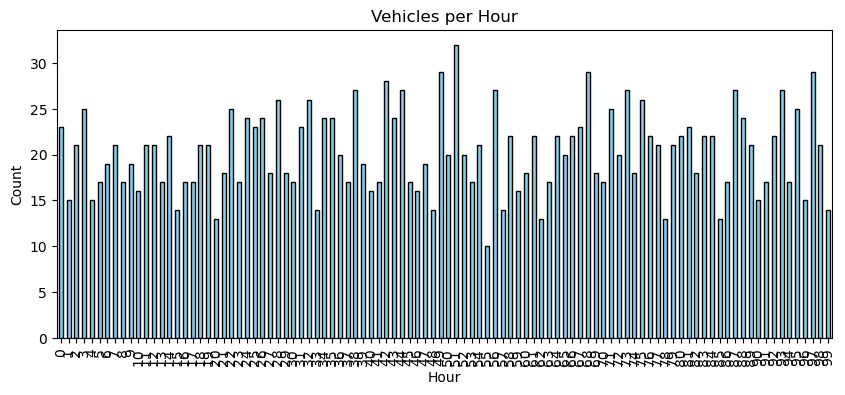

KS test for Normal: statistic=0.1103, p-value=0.1628


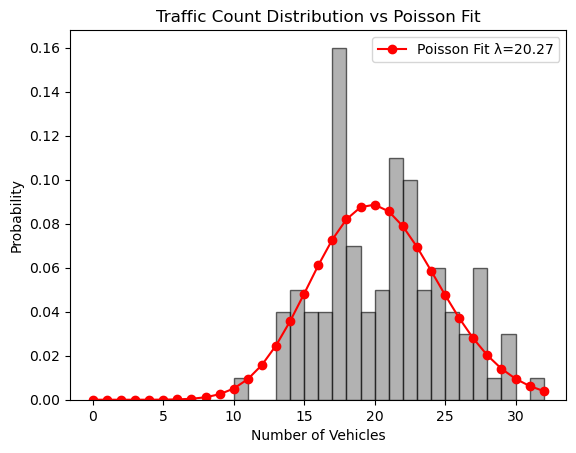

Decision: Poisson distribution seems reasonable for modeling vehicle counts per hour.
Random Forest MSE: 23.10


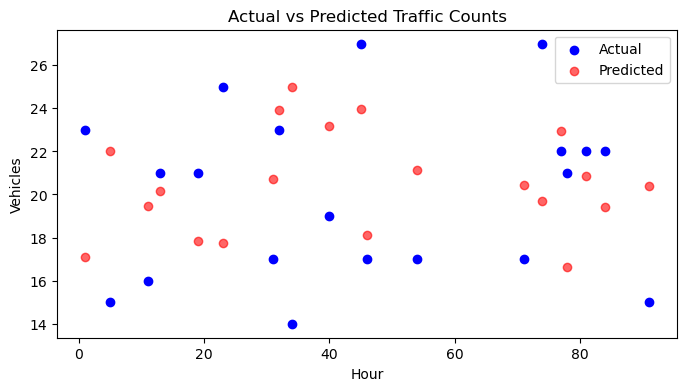

In [9]:
# Your code here

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Q20: Load real dataset
# Example: synthetic traffic counts per hour

np.random.seed(42)
traffic_data = pd.DataFrame({
    'hour': np.arange(1, 101),
    'vehicles': np.random.poisson(lam=20, size=100)
})

print(traffic_data.head())
traffic_data['vehicles'].plot(kind='bar', figsize=(10,4), color='skyblue', edgecolor='black')
plt.title("Vehicles per Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# Q21: Identify best-fitting distribution

from scipy.stats import kstest

# Normal fit

mu, std = norm.fit(traffic_data['vehicles'])
ks_stat, p_value = kstest(traffic_data['vehicles'], 'norm', args=(mu, std))
print(f"KS test for Normal: statistic={ks_stat:.4f}, p-value={p_value:.4f}")

# Poisson fit

lambda_poisson = traffic_data['vehicles'].mean()

# For Poisson, visual check

x = np.arange(0, traffic_data['vehicles'].max()+1)
plt.hist(traffic_data['vehicles'], bins=x, density=True, alpha=0.6, color='gray', edgecolor='black')
plt.plot(x, poisson.pmf(x, lambda_poisson), 'o-', color='red', label=f'Poisson Fit λ={lambda_poisson:.2f}')
plt.title("Traffic Count Distribution vs Poisson Fit")
plt.xlabel("Number of Vehicles")
plt.ylabel("Probability")
plt.legend()
plt.show()

print("Decision: Poisson distribution seems reasonable for modeling vehicle counts per hour.")

# Q22: Build small ML model

# Features: hour; Target: vehicles

X = traffic_data[['hour']]
y = traffic_data['vehicles']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Random Forest MSE: {mse:.2f}")

# Plot predictions

plt.figure(figsize=(8,4))
plt.scatter(X_test, y_test, label='Actual', color='blue')
plt.scatter(X_test, y_pred, label='Predicted', color='red', alpha=0.6)
plt.title("Actual vs Predicted Traffic Counts")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.legend()
plt.show()